In [1]:
import requests
from pprint import pprint
import matplotlib.pyplot as plt 
import time
import numpy as np
import math

In [5]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import pytz
pd.set_option('display.max_columns', 500) # number of columns to be displayed
pd.set_option('display.width', 1500)      # max table width to display
 
# establish connection to MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

timezone = pytz.timezone("Etc/UTC")
# create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
x = datetime.now()
utc_from = datetime(2021, 4, 1, tzinfo=timezone)
utc_to = datetime(x.year, x.month, x.day+1, tzinfo=timezone)
# rates = mt5.copy_rates_from("EURUSD", mt5.TIMEFRAME_M30, utc_from,75)
rates = mt5.copy_rates_range("GBPUSD", mt5.TIMEFRAME_M30, utc_from, utc_to)

# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

rates_frame = pd.DataFrame(rates)
# convert time in seconds into the datetime format
rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
rates_frame = rates_frame.set_index('time')

print(len(rates_frame['close']))
rates_frame['ll'] = rates_frame['close'].rolling(window=100).mean()

686


In [4]:
c = 0
df = rates_frame.iloc[-147:]
for index, row in df.iterrows():
    try:
        if row['close'] > row['ll'] and rates_frame.iloc[index+1]['close'] < row['ll']:
#             print(rates_frame.iloc[index]['time'])
#             print(row['close'], row['ll'])
            a = datetime.now() - rates_frame.iloc[index]['time']
            if a.seconds <= 14000:
                c+= 1
        elif row['close'] < row['ll'] and rates_frame.iloc[index+1]['close'] > row['ll']:
#             print(rates_frame.iloc[index]['time'])
#             print(row['close'], row['ll'])
            a = datetime.now() - rates_frame.iloc[index]['time']
            if a.seconds <= 14000:
                c += 1
    except:
        pass
print(c)
if c:
    telegram_bot_sendtext("EURUSD Alert")
    

0


(array([18718., 18722., 18726., 18730., 18734., 18738.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

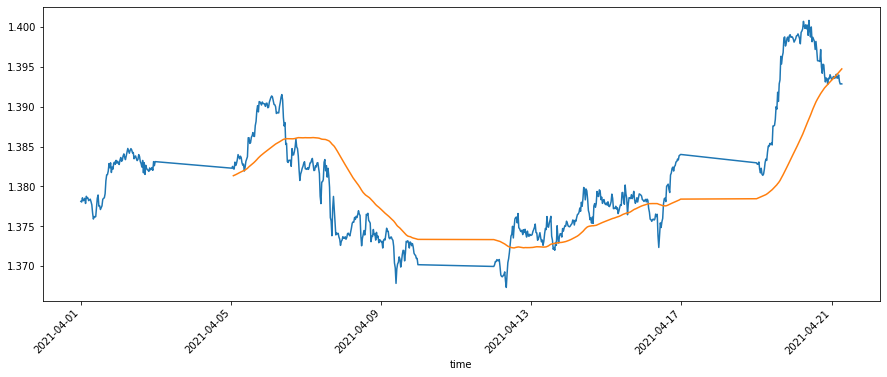

In [6]:
rates_frame['close'].plot(figsize=(15,6))
# rates_frame['ll'] = rates_frame['close'].rolling(window=100).mean()
rates_frame['ll'].plot()
# plt.plot( l[200:-100], 'r').rolling(window=100).

plt.xticks(rotation = 45)
# plt.ylim(1.19320,1.19350)
# plt.autoscale()

In [11]:
k = []
k = [i for i in rates_frame.index]
c = math.floor(len(k)/10)
print(c)
for i in k[-math.floor(len(k)/10):-1]:
#     try:
        if rates_frame['close'][i] > rates_frame['ll'][i] and rates_frame['close'][k[-(c+1)]] < rates_frame['ll'][i]:
            print(i)
            print(rates_frame['close'][i], rates_frame['ll'][i])
#             telegram_bot_sendtext("EURUSD")
#             print(rates_frame['close'][k[c+1]], rates_frame['ll'][i])           
        elif rates_frame['close'][i] < rates_frame['ll'][i] and rates_frame['close'][k[c+1]] > rates_frame['ll'][i]:
            print(i)
            print(rates_frame['close'][i], rates_frame['ll'][i])
#             telegram_bot_sendtext("EURUSD down")

        elif rates_frame['close'][i] == rates_frame['ll'][i]:
            print("_"*10)
            print(i)
            print(rates_frame['close'][i], rates_frame['ll'][i])
        c+=1
    #         break
#     except:
#         pass

#     break

50
485
0.86969 0.8678469
486
0.86952 0.8678744
487
0.86909 0.8679003000000001
488
0.86928 0.8679302999999998
489
0.86938 0.8679636000000001
490
0.86939 0.8679954
491
0.86932 0.8680266
492
0.8692 0.8680539
493
0.86941 0.8680847
494
0.8693 0.8681177
495
0.86949 0.8681548000000001
496
0.86953 0.8681913
497
0.86924 0.8682246
498
0.86899 0.8682559999999999


In [5]:
import requests

def telegram_bot_sendtext(bot_message):
    
    bot_token = '1789310123:AAHiV-IiAML2uNvtyeeCp6fBIXOpisR4_JM'
    bot_chatID = '220684438'
    send_text = 'https://api.telegram.org/bot' + bot_token + '/sendMessage?chat_id=' + bot_chatID + '&parse_mode=Markdown&text=' + bot_message

    response = requests.get(send_text)

    return response.json()
    

# test = telegram_bot_sendtext("Testing Telegram bot")
# print(test)


In [52]:
import time
import MetaTrader5 as mt5
 
# display data on the MetaTrader 5 package
print("MetaTrader5 package author: ", mt5.__author__)
print("MetaTrader5 package version: ", mt5.__version__)
 
# establish connection to the MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

# prepare the buy request structure
symbol = "USDJPY"
symbol_info = mt5.symbol_info(symbol)
if symbol_info is None:
    print(symbol, "not found, can not call order_check()")
    mt5.shutdown()
    quit()

# if the symbol is unavailable in MarketWatch, add it
if not symbol_info.visible:
    print(symbol, "is not visible, trying to switch on")
    if not mt5.symbol_select(symbol,True):
        print("symbol_select({}}) failed, exit",symbol)
        mt5.shutdown()
        quit()
lot = 0.01
poin = mt5.symbol_info(symbol)
print("---->{}")
# print(help(poin))
point = poin.point
price = mt5.symbol_info_tick(symbol).bid
print(100 * point)
print(price - 0.1)
print(price + 0.1)
deviation = 200
request = {
    "action": mt5.TRADE_ACTION_DEAL,
    "symbol": symbol,
    "volume": lot,
    "type": mt5.ORDER_TYPE_SELL,
    "price": price,

    "deviation": deviation,
    "magic": 234000,
    "comment": "python script open",
    "type_time": mt5.ORDER_TIME_GTC,
    "type_filling": mt5.ORDER_FILLING_RETURN,
}
#      "sl": price - 100 * point,
#     "tp": price + 100 * point,
# send a trading request
result = mt5.order_send(request)
# check the execution result
print("1. order_send(): by {} {} lots at {} with deviation={} points".format(symbol,lot,price,deviation));
if result.retcode != mt5.TRADE_RETCODE_DONE:
    print("2. order_send failed, retcode={}".format(result.retcode))
    # request the result as a dictionary and display it element by element
    result_dict=result._asdict()
    for field in result_dict.keys():
        print("   {}={}".format(field,result_dict[field]))
        # if this is a trading request structure, display it element by element as well
        if field=="request":
            traderequest_dict=result_dict[field]._asdict()
            for tradereq_filed in traderequest_dict:
                print("       traderequest: {}={}".format(tradereq_filed,traderequest_dict[tradereq_filed]))
    print("shutdown() and quit")
    mt5.shutdown()
    quit()

print("2. order_send done, ", result)
print("   opened position with POSITION_TICKET={}".format(result.order))
print("   sleep 2 seconds before closing position #{}".format(result.order))
time.sleep(2)

mt5.shutdown()

MetaTrader5 package author:  MetaQuotes Software Corp.
MetaTrader5 package version:  5.0.34
---->{}
0.1
110.763
110.963
1. order_send(): by USDJPY 0.01 lots at 110.863 with deviation=200 points
2. order_send done,  OrderSendResult(retcode=10009, deal=1007853956, order=1024090056, volume=0.01, price=110.863, bid=110.863, ask=110.865, comment='Request executed', request_id=15, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='USDJPY', volume=0.01, price=110.863, stoplimit=0.0, sl=0.0, tp=0.0, deviation=200, type=1, type_filling=2, type_time=0, expiration=0, comment='python script open', position=0, position_by=0))
   opened position with POSITION_TICKET=1024090056
   sleep 2 seconds before closing position #1024090056


True

In [49]:
from pprint import pprint

In [46]:
pp = 0.01*10000*point
takeP = (0.50/pp)*point
print(takeP)
print(110.932+takeP)

0.005
110.937


In [40]:
pprint(poin)

SymbolInfo(custom=False, chart_mode=0, select=True, visible=True, session_deals=0, session_buy_orders=0, session_sell_orders=0, volume=0, volumehigh=0, volumelow=0, time=1624891802, digits=3, spread=1, spread_float=True, ticks_bookdepth=10, trade_calc_mode=0, trade_mode=4, start_time=0, expiration_time=0, trade_stops_level=0, trade_freeze_level=0, trade_exemode=1, swap_mode=1, swap_rollover3days=3, margin_hedged_use_leg=False, expiration_mode=7, filling_mode=1, order_mode=127, order_gtc_mode=0, option_mode=0, option_right=0, bid=110.931, bidhigh=110.933, bidlow=110.617, ask=110.932, askhigh=110.934, asklow=110.617, last=0.0, lasthigh=0.0, lastlow=0.0, volume_real=0.0, volumehigh_real=0.0, volumelow_real=0.0, option_strike=0.0, point=0.001, trade_tick_value=0.9014531424656548, trade_tick_value_profit=0.9014531424656548, trade_tick_value_loss=0.9014612687165895, trade_tick_size=0.001, trade_contract_size=100000.0, trade_accrued_interest=0.0, trade_face_value=0.0, trade_liquidity_rate=0.0

In [41]:
point

0.001

In [9]:
result.order

1023845593

In [30]:
mt5.symbol_info_tick(symbol)

In [55]:
#close order
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()
symbol = "USDJPY"
position_id=result.order
price=mt5.symbol_info_tick(symbol).ask
deviation=20
request={
    "action": mt5.TRADE_ACTION_DEAL,
    "symbol": symbol,
    "volume": lot,
    "type": mt5.ORDER_TYPE_BUY,
    "position": position_id,
    "price": price,
    "deviation": deviation,
    "magic": 234000,
    "comment": "python script close",
    "type_time": mt5.ORDER_TIME_GTC,
    "type_filling": mt5.ORDER_FILLING_RETURN,
}
# send a trading request
result=mt5.order_send(request)
# check the execution result
print("3. close position #{}: sell {} {} lots at {} with deviation={} points".format(position_id,symbol,lot,price,deviation));
if result.retcode != mt5.TRADE_RETCODE_DONE:
    print("4. order_send failed, retcode={}".format(result.retcode))
    print("   result",result)
else:
    print("4. position #{} closed, {}".format(position_id,result))
    # request the result as a dictionary and display it element by element
    result_dict=result._asdict()
    for field in result_dict.keys():
        print("   {}={}".format(field,result_dict[field]))
        # if this is a trading request structure, display it element by element as well
        if field=="request":
            traderequest_dict=result_dict[field]._asdict()
            for tradereq_filed in traderequest_dict:
                print("       traderequest: {}={}".format(tradereq_filed,traderequest_dict[tradereq_filed]))
# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

3. close position #1024091427: sell USDJPY 0.01 lots at 110.838 with deviation=20 points
4. position #1024091427 closed, OrderSendResult(retcode=10009, deal=1007856408, order=1024092448, volume=0.01, price=110.838, bid=110.836, ask=110.838, comment='Request executed', request_id=17, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='USDJPY', volume=0.01, price=110.838, stoplimit=0.0, sl=0.0, tp=0.0, deviation=20, type=0, type_filling=2, type_time=0, expiration=0, comment='python script close', position=1024091427, position_by=0))
   retcode=10009
   deal=1007856408
   order=1024092448
   volume=0.01
   price=110.838
   bid=110.836
   ask=110.838
   comment=Request executed
   request_id=17
   retcode_external=0
   request=TradeRequest(action=1, magic=234000, order=0, symbol='USDJPY', volume=0.01, price=110.838, stoplimit=0.0, sl=0.0, tp=0.0, deviation=20, type=0, type_filling=2, type_time=0, expiration=0, comment='python script close', position=1024091427

True

In [27]:
#profit checker
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()
order_status = mt5.positions_get(ticket=1023845593)
Ticket_profit = order_status[0].profit
print(Ticket_profit)
mt5.shutdown()

-0.05


True

In [28]:
import MetaTrader5 as mt5
import pandas as pd
pd.set_option('display.max_columns', 500) # number of columns to be displayed
pd.set_option('display.width', 1500)      # max table width to display
# display data on the MetaTrader 5 package
print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)
print()
# establish connection to the MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()
 # get open positions on USDCHF
positions=mt5.positions_get(symbol="USDJPY")
if positions==None:
    print("No positions on USDCHF, error code={}".format(mt5.last_error()))
elif len(positions)>0:
    print("Total positions on USDCHF =",len(positions))
    # display all open positions
    for position in positions:
        print(position)
# get the list of positions on symbols whose names contain "*USD*"
usd_positions=mt5.positions_get(group="*USD*")
if usd_positions==None:
    print("No positions with group=\"*USD*\", error code={}".format(mt5.last_error()))
elif len(usd_positions)>0:
    print("positions_get(group=\"*USD*\")={}".format(len(usd_positions)))
    # display these positions as a table using pandas.DataFrame
    df=pd.DataFrame(list(usd_positions),columns=usd_positions[0]._asdict().keys())
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.drop(['time_update', 'time_msc', 'time_update_msc', 'external_id'], axis=1, inplace=True)
    print(df)
# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()
 

MetaTrader5 package author:  MetaQuotes Software Corp.
MetaTrader5 package version:  5.0.34

Total positions on USDCHF = 2
TradePosition(ticket=1023844774, time=1624885195, time_msc=1624885195932, time_update=1624885195, time_update_msc=1624885195932, type=0, magic=234000, identifier=1023844774, reason=3, volume=0.01, price_open=110.722, sl=110.622, tp=110.822, price_current=110.71, swap=0.0, profit=-0.11, symbol='USDJPY', comment='python script op', external_id='')
TradePosition(ticket=1023845593, time=1624885232, time_msc=1624885232476, time_update=1624885232, time_update_msc=1624885232476, type=0, magic=234000, identifier=1023845593, reason=3, volume=0.01, price_open=110.722, sl=0.0, tp=0.0, price_current=110.71, swap=0.0, profit=-0.11, symbol='USDJPY', comment='python script op', external_id='')
positions_get(group="*USD*")=2
       ticket                time  type   magic  identifier  reason  volume  price_open       sl       tp  price_current  swap  profit  symbol           comme

True

In [7]:
import time
import MetaTrader5 as mt5
 
# display data on the MetaTrader 5 package
print("MetaTrader5 package author: ", mt5.__author__)
print("MetaTrader5 package version: ", mt5.__version__)
 
# establish connection to the MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

# prepare the buy request structure
symbol = "USDJPY"
symbol_info = mt5.symbol_info(symbol)
if symbol_info is None:
    print(symbol, "not found, can not call order_check()")
    mt5.shutdown()
    quit()

# if the symbol is unavailable in MarketWatch, add it
if not symbol_info.visible:
    print(symbol, "is not visible, trying to switch on")
    if not mt5.symbol_select(symbol,True):
        print("symbol_select({}}) failed, exit",symbol)
        mt5.shutdown()
        quit()
lot = 0.01
point = mt5.symbol_info(symbol).point
price = mt5.symbol_info_tick(symbol).bid
deviation = 200
request = {
    "action": mt5.TRADE_ACTION_DEAL,
    "symbol": symbol,
    "volume": lot,
    "type": mt5.ORDER_TYPE_SELL,
    "price": price,
    "sl": price + 100 * point,
    "tp": price - 100 * point,
    "deviation": deviation,
    "magic": 234001,
    "comment": "python script open",
    "type_time": mt5.ORDER_TIME_GTC,
    "type_filling": mt5.ORDER_FILLING_RETURN,
}
 
# send a trading request
result = mt5.order_send(request)
# check the execution result
print("1. order_send(): by {} {} lots at {} with deviation={} points".format(symbol,lot,price,deviation));
if result.retcode != mt5.TRADE_RETCODE_DONE:
    print("2. order_send failed, retcode={}".format(result.retcode))
    # request the result as a dictionary and display it element by element
    result_dict=result._asdict()
    for field in result_dict.keys():
        print("   {}={}".format(field,result_dict[field]))
        # if this is a trading request structure, display it element by element as well
        if field=="request":
            traderequest_dict=result_dict[field]._asdict()
            for tradereq_filed in traderequest_dict:
                print("       traderequest: {}={}".format(tradereq_filed,traderequest_dict[tradereq_filed]))
    print("shutdown() and quit")
    mt5.shutdown()
    quit()

print("2. order_send done, ", result)
print("   opened position with POSITION_TICKET={}".format(result.order))
print("   sleep 2 seconds before closing position #{}".format(result.order))
time.sleep(2)

mt5.shutdown()

MetaTrader5 package author:  MetaQuotes Software Corp.
MetaTrader5 package version:  5.0.34
1. order_send(): by USDJPY 0.01 lots at 108.903 with deviation=200 points
2. order_send done,  OrderSendResult(retcode=10009, deal=968663415, order=985416890, volume=0.01, price=108.903, bid=108.903, ask=108.904, comment='Request executed', request_id=7, retcode_external=0, request=TradeRequest(action=1, magic=234001, order=0, symbol='USDJPY', volume=0.01, price=108.903, stoplimit=0.0, sl=109.003, tp=108.80300000000001, deviation=200, type=1, type_filling=2, type_time=0, expiration=0, comment='python script open', position=0, position_by=0))
   opened position with POSITION_TICKET=985416890
   sleep 2 seconds before closing position #985416890


True

In [8]:
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

# prepare the buy request structure
symbol = "USDJPY"
symbol_info = mt5.symbol_info(symbol)
if symbol_info is None:
    print(symbol, "not found, can not call order_check()")
    mt5.shutdown()
    quit()

# if the symbol is unavailable in MarketWatch, add it
if not symbol_info.visible:
    print(symbol, "is not visible, trying to switch on")
    if not mt5.symbol_select(symbol,True):
        print("symbol_select({}}) failed, exit",symbol)
        mt5.shutdown()
        quit()
#create a close request
position_id=result.order
price=mt5.symbol_info_tick(symbol).ask
deviation=200
request={
    "action": mt5.TRADE_ACTION_DEAL,
    "symbol": symbol,
    "volume": lot,
    "type": mt5.ORDER_TYPE_BUY,
    "position": position_id,
    "price": price,
    "deviation": deviation,
    "magic": 234001,
    "comment": "python script close",
    "type_time": mt5.ORDER_TIME_GTC,
    "type_filling": mt5.ORDER_FILLING_RETURN,
}
# send a trading request
result=mt5.order_send(request)
# check the execution result
print("3. close position #{}: sell {} {} lots at {} with deviation={} points".format(position_id,symbol,lot,price,deviation));
if result.retcode != mt5.TRADE_RETCODE_DONE:
    print("4. order_send failed, retcode={}".format(result.retcode))
    print("   result",result)
else:
    print("4. position #{} closed, {}".format(position_id,result))
    # request the result as a dictionary and display it element by element
    result_dict=result._asdict()
    for field in result_dict.keys():
        print("   {}={}".format(field,result_dict[field]))
        # if this is a trading request structure, display it element by element as well
        if field=="request":
            traderequest_dict=result_dict[field]._asdict()
            for tradereq_filed in traderequest_dict:
                print("       traderequest: {}={}".format(tradereq_filed,traderequest_dict[tradereq_filed]))
mt5.shutdown()
#shut down connection to the MetaTrader 5 terminal

3. close position #985416890: sell USDJPY 0.01 lots at 108.904 with deviation=200 points
4. position #985416890 closed, OrderSendResult(retcode=10009, deal=968663630, order=985417099, volume=0.01, price=108.904, bid=108.904, ask=108.904, comment='Request executed', request_id=8, retcode_external=0, request=TradeRequest(action=1, magic=234001, order=0, symbol='USDJPY', volume=0.01, price=108.904, stoplimit=0.0, sl=0.0, tp=0.0, deviation=200, type=0, type_filling=2, type_time=0, expiration=0, comment='python script close', position=985416890, position_by=0))
   retcode=10009
   deal=968663630
   order=985417099
   volume=0.01
   price=108.904
   bid=108.904
   ask=108.904
   comment=Request executed
   request_id=8
   retcode_external=0
   request=TradeRequest(action=1, magic=234001, order=0, symbol='USDJPY', volume=0.01, price=108.904, stoplimit=0.0, sl=0.0, tp=0.0, deviation=200, type=0, type_filling=2, type_time=0, expiration=0, comment='python script close', position=985416890, posit

True

In [3]:
mt5.shutdown()

True